In [3]:
import sys
import warnings

if not sys.warnoptions:
    warnings.simplefilter('ignore')

In [4]:
import tensorflow.compat.v1 as tf
tf.disable_v2_behavior()
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from datetime import datetime
from datetime import timedelta
from tqdm import tqdm
sns.set()
tf.compat.v1.random.set_random_seed(1234)

2026-03-03 02:48:09.592150: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-03-03 02:48:09.592397: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-03 02:48:09.629467: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-03 02:48:10.636966: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To tur

Instructions for updating:
non-resource variables are not supported in the long term


In [5]:
df = pd.read_csv('../dataset/GOOG-year.csv')
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2016-11-02,778.200012,781.650024,763.450012,768.700012,768.700012,1872400
1,2016-11-03,767.250000,769.950012,759.030029,762.130005,762.130005,1943200
2,2016-11-04,750.659973,770.359985,750.560974,762.020020,762.020020,2134800
3,2016-11-07,774.500000,785.190002,772.549988,782.520020,782.520020,1585100
4,2016-11-08,783.400024,795.632996,780.190002,790.510010,790.510010,1350800


In [6]:
minmax = MinMaxScaler().fit(df.iloc[:, 4:5].astype('float32')) # Close index
df_log = minmax.transform(df.iloc[:, 4:5].astype('float32')) # Close index
df_log = pd.DataFrame(df_log)
df_log.head()

,0
0,0.112708
1,0.090008
2,0.089628
3,0.160459
4,0.188066


## Split train and test

I will cut the dataset to train and test datasets,

1. Train dataset derived from starting timestamp until last 30 days
2. Test dataset derived from last 30 days until end of the dataset

So we will let the model do forecasting based on last 30 days, and we will going to repeat the experiment for 10 times. You can increase it locally if you want, and tuning parameters will help you by a lot.

In [7]:
test_size = 30
simulation_size = 10

df_train = df_log.iloc[:-test_size]
df_test = df_log.iloc[-test_size:]
df.shape, df_train.shape, df_test.shape

((252, 7), (222, 1), (30, 1))

In [20]:
class Model:
    def __init__(
        self,
        learning_rate,
        num_layers,
        size,
        size_layer,
        output_size,
        forget_bias = 0.1,
    ):
        self.X = tf.compat.v1.placeholder(tf.float32, (None, None, size))
        self.Y = tf.compat.v1.placeholder(tf.float32, (None, output_size))

        # Flattened hidden-state placeholder: [h0, c0, h1, c1, ...] concatenated.
        self.hidden_layer = tf.compat.v1.placeholder(
            tf.float32, (None, num_layers * 2 * size_layer)
        )
        hidden_parts = tf.split(self.hidden_layer, num_layers * 2, axis = 1)

        # Use tf.compat.v1.nn.dynamic_rnn with Keras LSTMCells stacked layer-by-layer.
        # This avoids tf.keras.layers.RNN which cannot handle TF1 symbolic (?) dimensions.
        rnn_input = self.X
        all_final_states = []
        for i in range(num_layers):
            cell = tf.keras.layers.LSTMCell(size_layer, dropout = 1 - forget_bias)
            h = hidden_parts[2 * i]
            c = hidden_parts[2 * i + 1]
            # LSTMCell.state_size = [h_size, c_size] → initial_state matches as a list.
            rnn_out, final_state = tf.compat.v1.nn.dynamic_rnn(
                cell, rnn_input, initial_state = [h, c], dtype = tf.float32
            )
            rnn_input = rnn_out                      # (batch, timesteps, size_layer)
            all_final_states.extend(final_state)     # [final_h, final_c] per layer

        self.outputs = rnn_input
        self.last_state = tf.concat(all_final_states, axis = 1)

        dense = tf.keras.layers.Dense(output_size)
        self.logits = dense(self.outputs[0])
        self.cost = tf.reduce_mean(tf.square(self.Y - self.logits))
        self.optimizer = tf.compat.v1.train.AdamOptimizer(learning_rate).minimize(
            self.cost
        )

def calculate_accuracy(real, predict):
    real = np.array(real) + 1
    predict = np.array(predict) + 1
    percentage = 1 - np.sqrt(np.mean(np.square((real - predict) / real)))
    return percentage * 100

def anchor(signal, weight):
    buffer = []
    last = signal[0]
    for i in signal:
        smoothed_val = last * weight + (1 - weight) * i
        buffer.append(smoothed_val)
        last = smoothed_val
    return buffer


In [14]:
num_layers = 1
size_layer = 128
timestamp = 5
epoch = 300
dropout_rate = 0.8
future_day = test_size
learning_rate = 0.01

In [10]:
print(tf)
print(hasattr(tf, "compat"), hasattr(tf.compat.v1, "reset_default_graph"))


<module 'tensorflow.compat.v1' from '/home/wayne/Documents/UCI/Winter_2026/CS172B/project/Stock-Prediction-Models/venv/lib/python3.12/site-packages/tensorflow/_api/v2/compat/v1/__init__.py'>
True True


In [21]:
def forecast():
    tf.compat.v1.reset_default_graph()
    modelnn = Model(
        learning_rate, num_layers, df_log.shape[1], size_layer, df_log.shape[1], dropout_rate
    )
    sess = tf.compat.v1.InteractiveSession()
    sess.run(tf.compat.v1.global_variables_initializer())
    date_ori = pd.to_datetime(df.iloc[:, 0]).tolist()

    pbar = tqdm(range(epoch), desc = 'train loop')
    for i in pbar:
        init_value = np.zeros((1, num_layers * 2 * size_layer))
        total_loss, total_acc = [], []
        for k in range(0, df_train.shape[0] - 1, timestamp):
            index = min(k + timestamp, df_train.shape[0] - 1)
            batch_x = np.expand_dims(
                df_train.iloc[k : index, :].values, axis = 0
            )
            batch_y = df_train.iloc[k + 1 : index + 1, :].values
            logits, last_state, _, loss = sess.run(
                [modelnn.logits, modelnn.last_state, modelnn.optimizer, modelnn.cost],
                feed_dict = {
                    modelnn.X: batch_x,
                    modelnn.Y: batch_y,
                    modelnn.hidden_layer: init_value,
                },
            )        
            init_value = last_state
            total_loss.append(loss)
            total_acc.append(calculate_accuracy(batch_y[:, 0], logits[:, 0]))
        pbar.set_postfix(cost = np.mean(total_loss), acc = np.mean(total_acc))
    
    future_day = test_size

    output_predict = np.zeros((df_train.shape[0] + future_day, df_train.shape[1]))
    output_predict[0] = df_train.iloc[0]
    upper_b = (df_train.shape[0] // timestamp) * timestamp
    init_value = np.zeros((1, num_layers * 2 * size_layer))

    for k in range(0, (df_train.shape[0] // timestamp) * timestamp, timestamp):
        out_logits, last_state = sess.run(
            [modelnn.logits, modelnn.last_state],
            feed_dict = {
                modelnn.X: np.expand_dims(
                    df_train.iloc[k : k + timestamp], axis = 0
                ),
                modelnn.hidden_layer: init_value,
            },
        )
        init_value = last_state
        output_predict[k + 1 : k + timestamp + 1] = out_logits

    if upper_b != df_train.shape[0]:
        out_logits, last_state = sess.run(
            [modelnn.logits, modelnn.last_state],
            feed_dict = {
                modelnn.X: np.expand_dims(df_train.iloc[upper_b:], axis = 0),
                modelnn.hidden_layer: init_value,
            },
        )
        output_predict[upper_b + 1 : df_train.shape[0] + 1] = out_logits
        future_day -= 1
        date_ori.append(date_ori[-1] + timedelta(days = 1))

    init_value = last_state
    
    for i in range(future_day):
        o = output_predict[-future_day - timestamp + i:-future_day + i]
        out_logits, last_state = sess.run(
            [modelnn.logits, modelnn.last_state],
            feed_dict = {
                modelnn.X: np.expand_dims(o, axis = 0),
                modelnn.hidden_layer: init_value,
            },
        )
        init_value = last_state
        output_predict[-future_day + i] = out_logits[-1]
        date_ori.append(date_ori[-1] + timedelta(days = 1))
    
    output_predict = minmax.inverse_transform(output_predict)
    deep_future = anchor(output_predict[:, 0], 0.3)
    
    return deep_future[-test_size:]

In [22]:
results = []
for i in range(simulation_size):
    print(f"simulation {i + 1}")
    try:
        results.append(forecast())
    except Exception as e:
        print(f"simulation {i + 1} failed: {e}")


simulation 1
Instructions for updating:
Please use `keras.layers.RNN(cell)`, which is equivalent to this API


E0000 00:00:1772535249.487914  350252 cuda_executor.cc:1309] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1772535249.495076  350252 gpu_device.cc:2342] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...
I0000 00:00:1772535249.609172  350252 mlir_graph_optimization_pass.cc:437] MLIR V1 optimization pass is not enabled
train loop: 100%|██████████| 300/300 [00:14<00:00, 20.24it/s, acc=97.9, cost=0.00105] 


simulation 2
ERROR:tensorflow:An interactive session is already active. This can cause out-of-memory errors or some other unexpected errors (due to the unpredictable timing of garbage collection) in some cases. You must explicitly call `InteractiveSession.close()` to release resources held by the other session(s). Please use `tf.Session()` if you intend to productionize.


E0000 00:00:1772535264.679191  350252 cuda_executor.cc:1309] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1772535264.680911  350252 gpu_device.cc:2342] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...
train loop: 100%|██████████| 300/300 [00:14<00:00, 20.26it/s, acc=96.8, cost=0.00304]


simulation 3
ERROR:tensorflow:An interactive session is already active. This can cause out-of-memory errors or some other unexpected errors (due to the unpredictable timing of garbage collection) in some cases. You must explicitly call `InteractiveSession.close()` to release resources held by the other session(s). Please use `tf.Session()` if you intend to productionize.


...

E0000 00:00:1772535358.529356  350252 cuda_executor.cc:1309] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1772535358.537119  350252 gpu_device.cc:2342] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...
train loop: 100%|██████████| 300/300 [00:15<00:00, 19.73it/s, acc=97.4, cost=0.00197]


simulation 9
ERROR:tensorflow:An interactive session is already active. This can cause out-of-memory errors or some other unexpected errors (due to the unpredictable timing of garbage collection) in some cases. You must explicitly call `InteractiveSession.close()` to release resources held by the other session(s). Please use `tf.Session()` if you intend to productionize.


E0000 00:00:1772535373.970783  350252 cuda_executor.cc:1309] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1772535373.978162  350252 gpu_device.cc:2342] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...
train loop: 100%|██████████| 300/300 [00:15<00:00, 18.93it/s, acc=96.5, cost=0.0035] 


simulation 10
ERROR:tensorflow:An interactive session is already active. This can cause out-of-memory errors or some other unexpected errors (due to the unpredictable timing of garbage collection) in some cases. You must explicitly call `InteractiveSession.close()` to release resources held by the other session(s). Please use `tf.Session()` if you intend to productionize.


E0000 00:00:1772535390.060513  350252 cuda_executor.cc:1309] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1772535390.066322  350252 gpu_device.cc:2342] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...
train loop: 100%|██████████| 300/300 [00:16<00:00, 18.51it/s, acc=97.4, cost=0.00165]


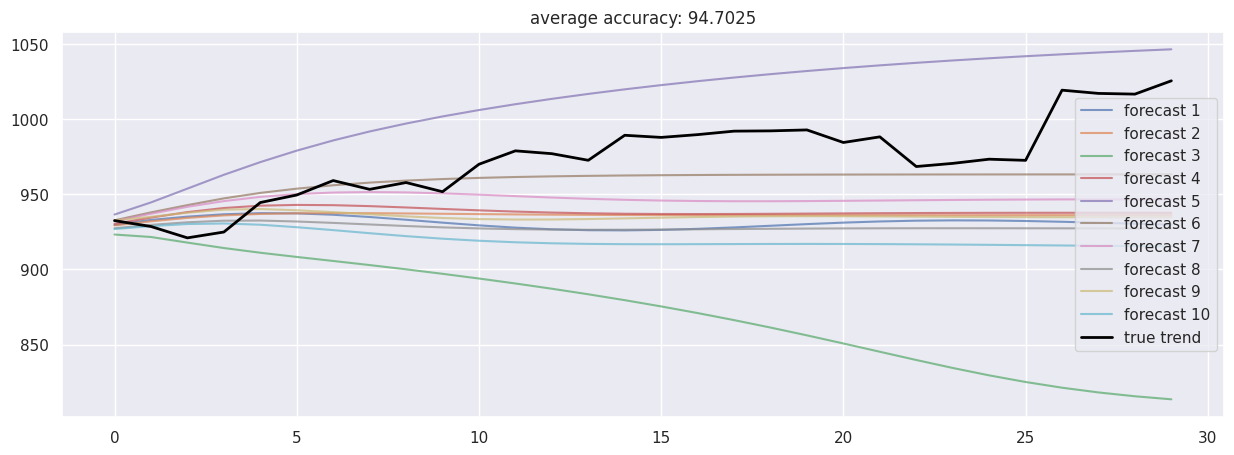

Forecast 1 individual accuracies: [np.float64(99.69208801905238), np.float64(99.529737645363), np.float64(98.46683136792942), np.float64(98.7237635414708), np.float64(99.25222399874376), np.float64(98.71275340785732), np.float64(97.62893059156855), np.float64(98.07040959618453), np.float64(97.41749946221212), np.float64(97.83996677968474), np.float64(95.81164518602738), np.float64(94.78398880536064), np.float64(94.8550883224869), np.float64(95.22075618674113), np.float64(93.60738758801045), np.float64(93.7750356473552), np.float64(93.67041581181459), np.float64(93.54810284966175), np.float64(93.64121236462269), np.float64(93.69246752090984), np.float64(94.58753415041026), np.float64(94.3078856544041), np.float64(96.28173424654278), np.float64(96.09628324473), np.float64(95.81283331765508), np.float64(95.85449175690628), np.float64(91.41505112621672), np.float64(91.54689646412248), np.float64(91.52395372325405), np.float64(90.67350206400783)]
Forecast 2 individual accuracies: [np.float6

In [27]:
valid_results = [r for r in results if r is not None and len(r) == test_size]

if not valid_results:
    raise ValueError("No valid forecasts in `results` (check forecast() errors and output length).")

y_true = df["Close"].iloc[-test_size:].values
accuracies = []
individual_accuracies = []

for r in valid_results:
    accuracies.append(calculate_accuracy(y_true, r))
    individual_accuracies.append([calculate_accuracy([y_true[i]], [r[i]]) for i in range(test_size)])

avg_forecast = np.mean(np.array(valid_results), axis=0)

plt.figure(figsize=(15, 5))
for no, r in enumerate(valid_results, 1):
    plt.plot(r, label=f"forecast {no}", alpha=0.35)

plt.plot(avg_forecast, label="average forecast", c="tab:red", linewidth=2.5)
plt.plot(y_true, label="true trend", c="black", linewidth=2)
plt.legend()
plt.title(f"average accuracy: {np.mean(accuracies):.4f}")
plt.show()

# Print individual accuracies for each forecast
for i, acc in enumerate(individual_accuracies, 1):
    print(f"Forecast {i} individual accuracies: {acc}")
